<a href="https://colab.research.google.com/github/kaushalkalas-awesome/DKTE-TY-DL/blob/main/DL_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, initializers, optimizers
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import time

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# --- Step 1: Load the Dataset ---
# MNIST is a dataset of 70,000 handwritten digits (0-9).
# The data is already split into a training set (60,000 images) and a testing set (10,000 images).
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# --- Step 2: Normalize the Image Data ---
# The pixel values in the images range from 0 (black) to 255 (white).
# Neural networks work best with small input values, so we scale the pixels to be between 0 and 1.
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# --- Step 3: Flatten the Images ---
# Our model will use "Dense" layers, which expect a flat list of numbers as input, not a 2D image.
# We reshape each 28x28 pixel image into a single long array of 784 pixels (28 * 28 = 784).
x_train = x_train.reshape(60000, 784)
x_test = x_test.reshape(10000, 784)

# --- Step 4: Convert Labels to "One-Hot" Format ---
# The labels are numbers from 0 to 9 (e.g., the image of a '7' has the label 7).
# We convert these numbers into a special format called "one-hot encoding".
# Example: The number 7 becomes [0,0,0,0,0,0,0,1,0,0].
# This format is needed for the loss function we will use to train the model.
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# --- Step 5: Verify the Data Shape ---
# Let's print the shapes to confirm our data is processed correctly.
print("Training data shape:", x_train.shape)      # Expected: (60000, 784)
print("Training labels shape:", y_train.shape)    # Expected: (60000, 10)
print("Testing data shape:", x_test.shape)        # Expected: (10000, 784)
print("Testing labels shape:", y_test.shape)      # Expected: (10000, 10)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 784)
Training labels shape: (60000, 10)
Testing data shape: (10000, 784)
Testing labels shape: (10000, 10)


In [ ]:
# --- Step 1: Define the Model's Architecture ---
# We create a function that builds the structure of our neural network.
# The only thing we allow to change is the 'initializer' (how the initial weights are set).
def build_model_architecture(initializer):
    """
    Builds the skeleton of our Multi-Layer Perceptron (MLP) model.

    Args:
        initializer: The recipe for setting the initial random weights.

    Returns:
        An uncompiled Keras model.
    """
    # A Sequential model is a simple stack of layers, one after the other.
    model = models.Sequential()

    # Layer 1: Input Layer + First Hidden Layer
    # - Dense: A fully connected layer. Every neuron is connected to every neuron in the next layer.
    # - 128: The number of neurons in this hidden layer.
    # - activation='relu': A common activation function that helps the model learn complex patterns.
    # - input_shape=(784,): We must tell the first layer the shape of our input data (flattened 28x28 images).
    # - kernel_initializer: Sets the initial weights for this layer using the specified recipe.
    model.add(layers.Dense(128, activation='relu', input_shape=(784,), kernel_initializer=initializer))

    # Layer 2: Second Hidden Layer
    # - 64: The number of neurons in this layer.
    # - We don't need input_shape here; Keras automatically figures it out from the previous layer.
    model.add(layers.Dense(64, activation='relu', kernel_initializer=initializer))

    # Layer 3: Output Layer
    # - 10: We need 10 neurons because there are 10 possible digits (0-9).
    # - activation='softmax': This function turns the outputs into probabilities,
    #   making it easy to pick the digit with the highest score.
    model.add(layers.Dense(10, activation='softmax', kernel_initializer=initializer))

    return model

# --- Step 2: Create and Compile the Models ---

# Let's create our three different models, one for each initialization strategy.

# Model 1: Using Random Normal initialization
# First, build the model structure...
random_normal_model = build_model_architecture(initializers.RandomNormal())
# Then, configure it for training.
random_normal_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Model 2: Using Glorot Uniform (Xavier) initialization
glorot_uniform_model = build_model_architecture(initializers.GlorotUniform())
glorot_uniform_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Model 3: Using He Normal initialization
he_normal_model = build_model_architecture(initializers.HeNormal())
he_normal_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("Models created and compiled successfully!")

# --- Step 3: Inspect a Model ---
# Let's look at the summary of one of our models to see its structure.
# The summary shows each layer, its output shape, and the number of trainable parameters (weights).
print("\nModel Summary (He Normal Initialization):")
print(he_normal_model.summary())

Models created and compiled successfully!

Model Summary (He Normal Initialization):


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
# --- Step 1: Define Training Parameters ---
# epochs: How many times the model will see the entire training dataset.
# batch_size: How many images to process before updating the model's weights.
epochs = 15
batch_size = 128

# --- Step 2: Create a Reusable Training Function ---
# This function will handle the entire training process for any given model.
# This is great because we don't have to repeat the same code three times!
def train_and_time_model(model, optimizer_name='adam', learning_rate=0.001):
    """
    Compiles, trains, and times a given Keras model.

    Args:
        model: The Keras model to train.
        optimizer_name: The algorithm to use for training ('sgd' or 'adam').
        learning_rate: How big of a step the optimizer takes.

    Returns:
        history: An object containing the training history (loss, accuracy, etc.).
        training_time: The total time taken to train the model in seconds.
    """
    # Choose the optimizer based on the name provided
    if optimizer_name.lower() == 'sgd':
        print(f"Using SGD optimizer with learning rate {learning_rate}")
        optimizer = optimizers.SGD(learning_rate=learning_rate)
    else:  # Default to Adam
        print(f"Using Adam optimizer with learning rate {learning_rate}")
        optimizer = optimizers.Adam(learning_rate=learning_rate)

    # Compile the model to prepare it for training
    # We must specify the optimizer, the loss function, and the metrics to track.
    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    # Start a timer to measure how long training takes
    start_time = time.time()

    # Train the model using the training data
    # validation_data: The model will be tested on this data after each epoch.
    # verbose=1: Shows a progress bar during training.
    print("Starting training...")
    history = model.fit(
        x_train, y_train,
        batch_size=batch_size,
        epochs=epochs,
        validation_data=(x_test, y_test),
        verbose=1  # Set to 0 to hide the progress bar
    )

    # Stop the timer and calculate the duration
    end_time = time.time()
    training_time = end_time - start_time

    return history, training_time

# --- Step 3: Train Each Model and Compare ---

# We will now train our three models, one by one, using the function we created.
# This allows us to see how the different initializers affect the training process.

# Train the model with Random Normal initialization
print("\n--- Training Model 1: Random Normal Initialization ---")
random_normal_history, rn_time = train_and_time_model(random_normal_model)
print(f"Training completed in {rn_time:.2f} seconds.\n")

# Train the model with Glorot Uniform (Xavier) initialization
print("--- Training Model 2: Glorot Uniform (Xavier) Initialization ---")
glorot_uniform_history, gu_time = train_and_time_model(glorot_uniform_model)
print(f"Training completed in {gu_time:.2f} seconds.\n")

# Train the model with He Normal initialization
print("--- Training Model 3: He Normal Initialization ---")
he_normal_history, hn_time = train_and_time_model(he_normal_model)
print(f"Training completed in {hn_time:.2f} seconds.\n")

print("All models have been trained successfully!")


--- Training Model 1: Random Normal Initialization ---
Using Adam optimizer with learning rate 0.001
Starting training...
Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.7983 - loss: 0.8025 - val_accuracy: 0.9364 - val_loss: 0.2109
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9434 - loss: 0.1971 - val_accuracy: 0.9565 - val_loss: 0.1419
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9610 - loss: 0.1339 - val_accuracy: 0.9649 - val_loss: 0.1125
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9700 - loss: 0.0991 - val_accuracy: 0.9694 - val_loss: 0.0958
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9772 - loss: 0.0767 - val_accuracy: 0.9724 - val_loss: 0.0863
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9823 - loss: 0.0610 - val_accuracy: 0.9725 - val_loss: 0.0820
Epoch 7/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9858 - loss: 0.0493 - val_accuracy: 0.9729

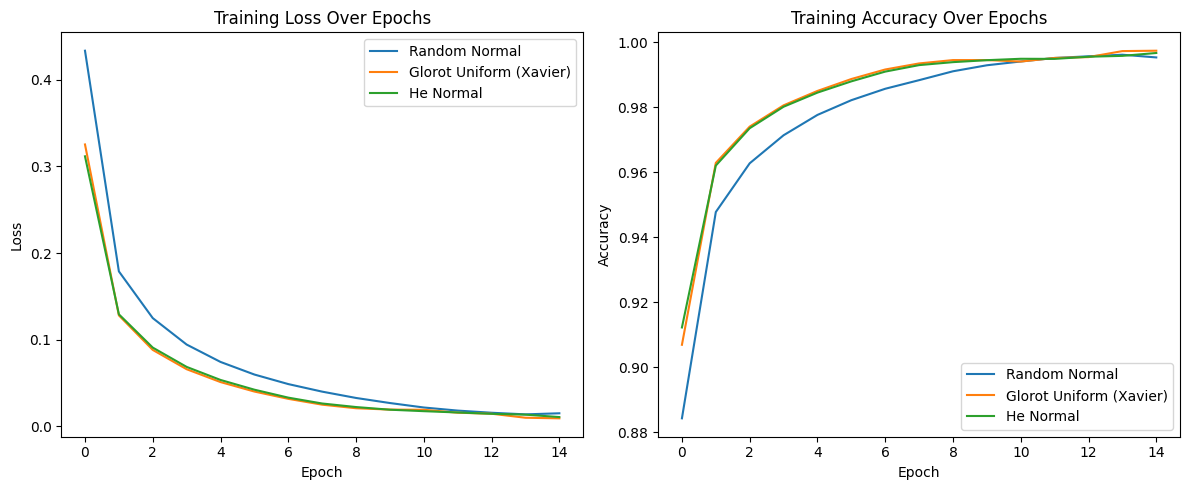


--- Final Performance Comparison ---

Final Training Accuracy:
Random Normal:  0.9954 (took 50.27 seconds)
Glorot Uniform: 0.9974 (took 50.27 seconds)
He Normal:      0.9967 (took 47.06 seconds)

Final Validation Accuracy (on unseen test data):
Random Normal:  0.9743
Glorot Uniform: 0.9768
He Normal:      0.9733


In [ ]:
# --- Part 1: Plotting the Learning Curves ---
# Visualizing the training process helps us see how each model learned over time.
# We'll create two plots side-by-side: one for loss and one for accuracy.

# Create a figure to hold our two plots
plt.figure(figsize=(12, 5))

# Plot 1: Training Loss
# A lower loss means the model's predictions are getting closer to the true labels.
plt.subplot(1, 2, 1)  # This means "1 row, 2 columns, select the 1st plot"
plt.plot(random_normal_history.history['loss'], label='Random Normal')
plt.plot(glorot_uniform_history.history['loss'], label='Glorot Uniform (Xavier)')
plt.plot(he_normal_history.history['loss'], label='He Normal')
plt.title('Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()  # Show the labels in the top corner

# Plot 2: Training Accuracy
# Higher accuracy means the model is classifying more images correctly.
plt.subplot(1, 2, 2)  # This means "1 row, 2 columns, select the 2nd plot"
plt.plot(random_normal_history.history['accuracy'], label='Random Normal')
plt.plot(glorot_uniform_history.history['accuracy'], label='Glorot Uniform (Xavier)')
plt.plot(he_normal_history.history['accuracy'], label='He Normal')
plt.title('Training Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Adjust the layout to make sure everything fits nicely
plt.tight_layout()
# Display the plots
plt.show()


# --- Part 2: Printing the Final Numbers ---
# While plots are great for trends, we also want the exact final performance numbers.
print("\n--- Final Performance Comparison ---")

# Print the final training accuracies and how long each model took to train
print("\nFinal Training Accuracy:")
print(f"Random Normal:  {random_normal_history.history['accuracy'][-1]:.4f} (took {rn_time:.2f} seconds)")
print(f"Glorot Uniform: {glorot_uniform_history.history['accuracy'][-1]:.4f} (took {rn_time:.2f} seconds)")
print(f"He Normal:      {he_normal_history.history['accuracy'][-1]:.4f} (took {hn_time:.2f} seconds)")

# Print the final validation accuracies
# Validation accuracy shows how well the model performs on data it has never seen before.
print("\nFinal Validation Accuracy (on unseen test data):")
print(f"Random Normal:  {random_normal_history.history['val_accuracy'][-1]:.4f}")
print(f"Glorot Uniform: {glorot_uniform_history.history['val_accuracy'][-1]:.4f}")
print(f"He Normal:      {he_normal_history.history['val_accuracy'][-1]:.4f}")

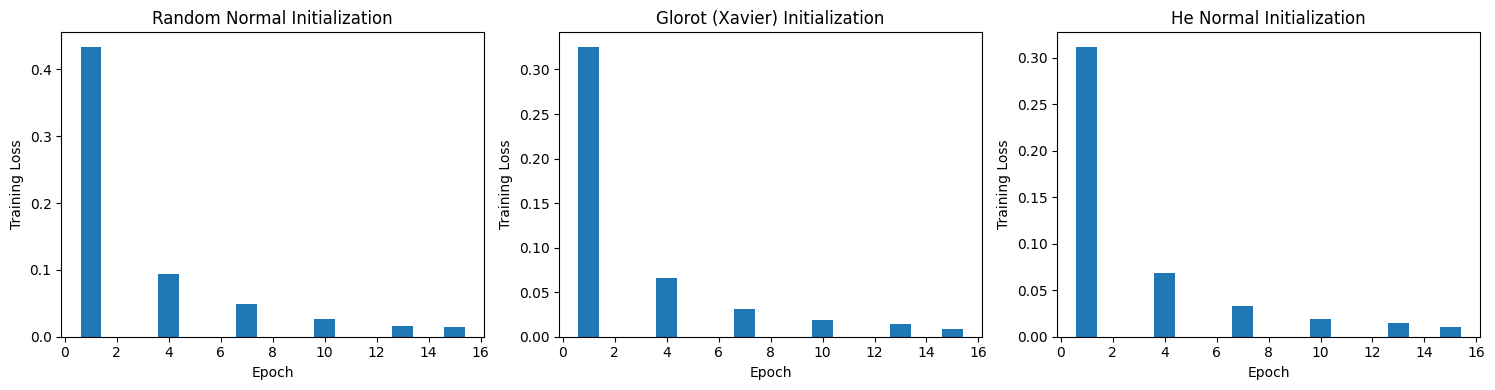

In [ ]:
import numpy as np

# Select specific epochs (1-based indexing)
selected_epochs = [1, 4, 7, 10, 13, 15]
epoch_indices = [e - 1 for e in selected_epochs]  # convert to 0-based index

plt.figure(figsize=(15, 4))

# --- Random Normal Initialization ---
plt.subplot(1, 3, 1)
plt.bar(
    selected_epochs,
    [random_normal_history.history['loss'][i] for i in epoch_indices]
)
plt.title('Random Normal Initialization')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')

# --- Glorot (Xavier) Initialization ---
plt.subplot(1, 3, 2)
plt.bar(
    selected_epochs,
    [glorot_uniform_history.history['loss'][i] for i in epoch_indices]
)
plt.title('Glorot (Xavier) Initialization')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')

# --- He Normal Initialization ---
plt.subplot(1, 3, 3)
plt.bar(
    selected_epochs,
    [he_normal_history.history['loss'][i] for i in epoch_indices]
)
plt.title('He Normal Initialization')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')

plt.tight_layout()
plt.show()


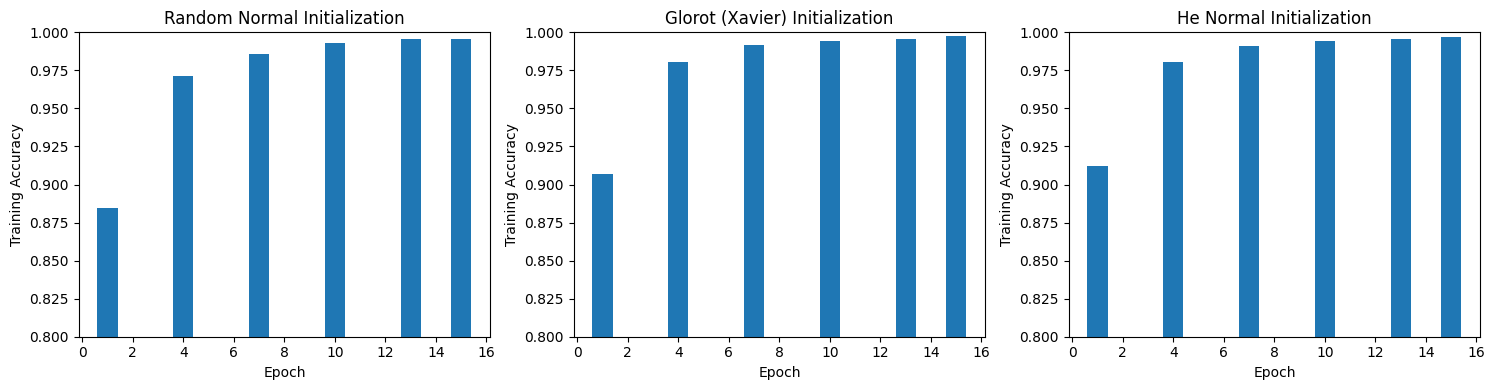

In [ ]:
import numpy as np

# Select specific epochs (1-based indexing)
selected_epochs = [1, 4, 7, 10, 13, 15]
epoch_indices = [e - 1 for e in selected_epochs]  # convert to 0-based index

plt.figure(figsize=(15, 4))

# --- Random Normal Initialization ---
plt.subplot(1, 3, 1)
plt.bar(
    selected_epochs,
    [random_normal_history.history['accuracy'][i] for i in epoch_indices]
)
plt.title('Random Normal Initialization')
plt.xlabel('Epoch')
plt.ylabel('Training Accuracy')
plt.ylim(0.8, 1.0)

# --- Glorot (Xavier) Initialization ---
plt.subplot(1, 3, 2)
plt.bar(
    selected_epochs,
    [glorot_uniform_history.history['accuracy'][i] for i in epoch_indices]
)
plt.title('Glorot (Xavier) Initialization')
plt.xlabel('Epoch')
plt.ylabel('Training Accuracy')
plt.ylim(0.8, 1.0)

# --- He Normal Initialization ---
plt.subplot(1, 3, 3)
plt.bar(
    selected_epochs,
    [he_normal_history.history['accuracy'][i] for i in epoch_indices]
)
plt.title('He Normal Initialization')
plt.xlabel('Epoch')
plt.ylabel('Training Accuracy')
plt.ylim(0.8, 1.0)

plt.tight_layout()
plt.show()


In [ ]:
# Based on the results, He Normal typically works best with ReLU
best_initializer = initializers.HeNormal()

# Create models for optimizer comparison
sgd_model = build_model_architecture(best_initializer)
adam_model = build_model_architecture(best_initializer)

# Train with SGD
print("Training with SGD optimizer...")
sgd_history, sgd_time = train_and_time_model(sgd_model, optimizer_name='sgd', learning_rate=0.01)

# Train with Adam
print("\nTraining with Adam optimizer...")
adam_history, adam_time = train_and_time_model(adam_model, optimizer_name='adam', learning_rate=0.001)

Training with SGD optimizer...
Using SGD optimizer with learning rate 0.01
Starting training...
Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5325 - loss: 1.6140 - val_accuracy: 0.8638 - val_loss: 0.5235
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8692 - loss: 0.4927 - val_accuracy: 0.8984 - val_loss: 0.3709
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8954 - loss: 0.3745 - val_accuracy: 0.9083 - val_loss: 0.3178
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9083 - loss: 0.3263 - val_accuracy: 0.9181 - val_loss: 0.2880
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9162 - loss: 0.2970 - val_accuracy: 0.9236 - val_loss: 0.2675
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9212 - loss: 0.2760 - val_accuracy: 0.9271 - val_loss: 0.2519
Epoch 7/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9262 - loss: 0.2594 - val_accuracy: 0.9310 - val_loss: 0.2393
Epoch 8/

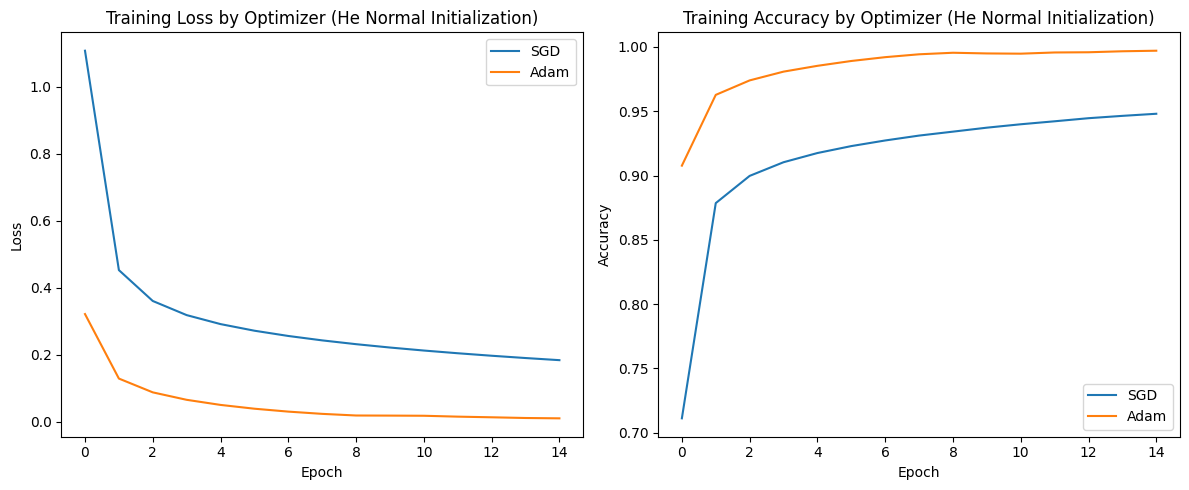


Final Training Accuracies:
SGD: 0.9480 (Time: 43.10s)
Adam: 0.9970 (Time: 67.47s)

Final Validation Accuracies:
SGD: 0.9462
Adam: 0.9744


In [ ]:
# Plot training loss for different optimizers
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(sgd_history.history['loss'], label='SGD')
plt.plot(adam_history.history['loss'], label='Adam')
plt.title('Training Loss by Optimizer (He Normal Initialization)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot training accuracy for different optimizers
plt.subplot(1, 2, 2)
plt.plot(sgd_history.history['accuracy'], label='SGD')
plt.plot(adam_history.history['accuracy'], label='Adam')
plt.title('Training Accuracy by Optimizer (He Normal Initialization)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

# Print final accuracies and training times
print("\nFinal Training Accuracies:")
print(f"SGD: {sgd_history.history['accuracy'][-1]:.4f} (Time: {sgd_time:.2f}s)")
print(f"Adam: {adam_history.history['accuracy'][-1]:.4f} (Time: {adam_time:.2f}s)")

print("\nFinal Validation Accuracies:")
print(f"SGD: {sgd_history.history['val_accuracy'][-1]:.4f}")
print(f"Adam: {adam_history.history['val_accuracy'][-1]:.4f}")

In [ ]:
# Create a summary table of results
results = {
    'Initialization': ['Random Normal', 'Glorot Uniform', 'He Normal'],
    'Final Training Accuracy': [
        random_normal_history.history['accuracy'][-1],
        glorot_uniform_history.history['accuracy'][-1],
        he_normal_history.history['accuracy'][-1]
    ],
    'Final Validation Accuracy': [
        random_normal_history.history['val_accuracy'][-1],
        glorot_uniform_history.history['val_accuracy'][-1],
        he_normal_history.history['val_accuracy'][-1]
    ],
    'Training Time (s)': [rn_time, gu_time, hn_time]
}

# Create optimizer comparison table
optimizer_results = {
    'Optimizer': ['SGD', 'Adam'],
    'Final Training Accuracy': [
        sgd_history.history['accuracy'][-1],
        adam_history.history['accuracy'][-1]
    ],
    'Final Validation Accuracy': [
        sgd_history.history['val_accuracy'][-1],
        adam_history.history['val_accuracy'][-1]
    ],
    'Training Time (s)': [sgd_time, adam_time]
}

import pandas as pd

print("\nWeight Initialization Comparison (with Adam optimizer):")
print(pd.DataFrame(results))

print("\nOptimizer Comparison (with He Normal initialization):")
print(pd.DataFrame(optimizer_results))

# Analyze convergence speed (epochs to reach 95% of final accuracy)
def get_convergence_epoch(history, threshold=0.95):
    final_acc = history.history['accuracy'][-1]
    target_acc = final_acc * threshold

    for epoch, acc in enumerate(history.history['accuracy']):
        if acc >= target_acc:
            return epoch + 1  # +1 because epochs are 0-indexed

    return len(history.history['accuracy'])  # If never reached threshold

print("\nConvergence Analysis:")
print(f"Random Normal: {get_convergence_epoch(random_normal_history)} epochs to reach 95% of final accuracy")
print(f"Glorot Uniform: {get_convergence_epoch(glorot_uniform_history)} epochs to reach 95% of final accuracy")
print(f"He Normal: {get_convergence_epoch(he_normal_history)} epochs to reach 95% of final accuracy")
print(f"SGD (with He Normal): {get_convergence_epoch(sgd_history)} epochs to reach 95% of final accuracy")
print(f"Adam (with He Normal): {get_convergence_epoch(adam_history)} epochs to reach 95% of final accuracy")


Weight Initialization Comparison (with Adam optimizer):
   Initialization  Final Training Accuracy  Final Validation Accuracy  \
0   Random Normal                 0.995383                     0.9743   
1  Glorot Uniform                 0.997450                     0.9768   
2       He Normal                 0.996750                     0.9733   

   Training Time (s)  
0          50.268909  
1          48.205813  
2          47.063235  

Optimizer Comparison (with He Normal initialization):
  Optimizer  Final Training Accuracy  Final Validation Accuracy  \
0       SGD                 0.948017                     0.9462   
1      Adam                 0.997033                     0.9744   

   Training Time (s)  
0          43.098899  
1          67.469921  

Convergence Analysis:
Random Normal: 2 epochs to reach 95% of final accuracy
Glorot Uniform: 2 epochs to reach 95% of final accuracy
He Normal: 2 epochs to reach 95% of final accuracy
SGD (with He Normal): 4 epochs to reach 95% of 